In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.6f}'.format)

PROJECT_DIR   = Path().resolve().parent
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
CHARTS_DIR    = PROJECT_DIR / 'reports' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = ['#1D9E75','#378ADD','#D85A30','#7F77DD','#BA7517',
           '#D4537E','#639922','#E24B4A','#888780','#185FA5']

RF_DAILY     = 0.065 / 252
TRADING_DAYS = 252

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
plt.rcParams.update({'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False})
print('Setup complete')

Setup complete


In [2]:
def load(name):
    for pat in [f'clean_{name}.csv', f'{name}.csv']:
        p = PROCESSED_DIR / pat
        if p.exists(): return pd.read_csv(p, low_memory=False)
    raw = PROJECT_DIR / 'data' / 'raw'
    for f in raw.iterdir():
        if name.replace('_','').lower() in f.stem.replace('_','').lower():
            return pd.read_csv(f, low_memory=False)
    print(f'  NOT FOUND: {name}'); return pd.DataFrame()

nav      = load('nav_history')
funds    = load('fund_master')
txn      = load('investor_transactions')
holdings = load('portfolio_holdings')
perf     = load('scheme_performance')
scorecard = load('fund_scorecard')

nav['date']             = pd.to_datetime(nav['date'],             errors='coerce')
nav['nav']              = pd.to_numeric(nav['nav'],               errors='coerce')
nav['amfi_code']        = nav['amfi_code'].astype(str)
funds['amfi_code']      = funds['amfi_code'].astype(str)
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'], errors='coerce')
txn['amount_inr']       = pd.to_numeric(txn['amount_inr'],        errors='coerce')

nav = nav.merge(
    funds[['amfi_code','scheme_name','fund_house','category','risk_category']],
    on='amfi_code', how='left')

nav = nav.sort_values(['amfi_code','date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav_r = nav.dropna(subset=['daily_return']).copy()
nav_r = nav_r[nav_r['daily_return'].between(-0.5, 0.5)]

for name_str, df in [('nav_history',nav),('fund_master',funds),
                     ('transactions',txn),('holdings',holdings)]:
    print(f'  {name_str:<25} {len(df):>8,} rows')

  nav_history                 64,320 rows
  fund_master                     40 rows
  transactions                32,778 rows
  holdings                       322 rows


In [3]:
var_rows = []
for code, grp in nav_r.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 30: continue
    var_95  = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({
        'amfi_code'          : code,
        'var_95_daily'       : round(var_95,  6),
        'cvar_95_daily'      : round(cvar_95, 6),
        'var_95_annual_pct'  : round(var_95  * np.sqrt(TRADING_DAYS) * 100, 4),
        'cvar_95_annual_pct' : round(cvar_95 * np.sqrt(TRADING_DAYS) * 100, 4),
        'n_days'             : len(r),
        'mean_daily_return'  : round(r.mean(), 6),
        'std_daily'          : round(r.std(),  6),
    })

var_df = (pd.DataFrame(var_rows)
          .merge(funds[['amfi_code','scheme_name','fund_house',
                         'category','risk_category']], on='amfi_code', how='left'))

var_df.to_csv(PROCESSED_DIR / 'var_cvar_report.csv', index=False)

disp = var_df.sort_values('var_95_daily').copy()
disp['var_95_daily']  = (disp['var_95_daily']  * 100).round(4)
disp['cvar_95_daily'] = (disp['cvar_95_daily'] * 100).round(4)
print('Funds with HIGHEST VaR (worst tail risk):')
display(disp[['scheme_name','category','risk_category',
              'var_95_daily','cvar_95_daily','var_95_annual_pct']].head(10))
print('\nSaved: var_cvar_report.csv')

Funds with HIGHEST VaR (worst tail risk):


,scheme_name,category,risk_category,var_95_daily,cvar_95_daily,var_95_annual_pct
4,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.391500,-3.028900,-37.963300
17,Axis Small Cap Fund - Regular - Growth,Equity,Very High,-2.328400,-2.969000,-36.961600
22,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,-2.315500,-3.016300,-36.758100
11,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,-2.281000,-2.994000,-36.209400
39,DSP Small Cap Fund - Regular - Growth,Equity,Very High,-2.152000,-2.857300,-34.162400
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,-2.150200,-2.844400,-34.133200
16,Axis Midcap Fund - Regular - Growth,Equity,High,-1.699700,-2.237500,-26.981200
29,Kotak Emerging Equity Fund - Regular - Growth,Equity,High,-1.695000,-2.125100,-26.907200
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-1.690200,-2.185000,-26.830500
7,UTI Mid Cap Fund - Regular - Growth,Equity,High,-1.685700,-2.177100,-26.759700



Saved: var_cvar_report.csv


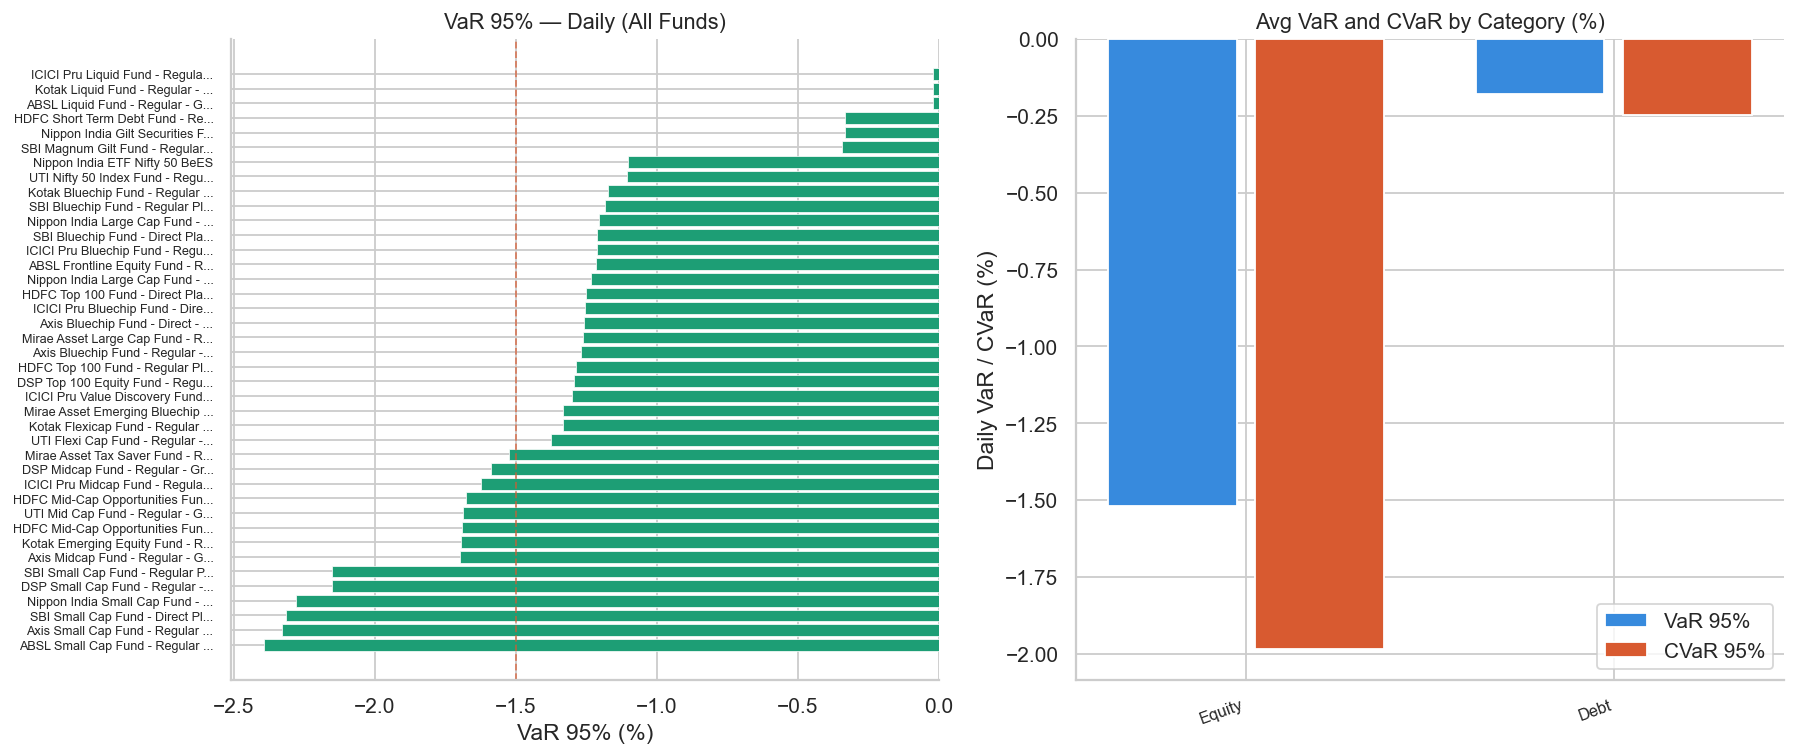

In [4]:
var_plot = var_df.dropna(subset=['var_95_daily','scheme_name']).sort_values('var_95_daily')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(var_plot)), var_plot['var_95_daily'] * 100,
             color=['#D85A30' if v < -1.5 else '#FAC775' if v < -1.0 else '#1D9E75'
                    for v in var_plot['var_95_daily']],
             edgecolor='white', linewidth=0.4)
axes[0].set_yticks(range(len(var_plot)))
axes[0].set_yticklabels(
    [s[:30]+'...' if len(str(s))>33 else str(s) for s in var_plot['scheme_name']],
    fontsize=7)
axes[0].set_title('VaR 95% — Daily (All Funds)', fontsize=12)
axes[0].set_xlabel('VaR 95% (%)')
axes[0].axvline(-1.5, color='#D85A30', linewidth=1, linestyle='--', alpha=0.7)

var_cat = var_df.groupby('category')[['var_95_daily','cvar_95_daily']].mean() * 100
var_cat = var_cat.sort_values('var_95_daily')
x = np.arange(len(var_cat))
axes[1].bar(x - 0.2, var_cat['var_95_daily'],  0.35,
            label='VaR 95%',  color='#378ADD', edgecolor='white')
axes[1].bar(x + 0.2, var_cat['cvar_95_daily'], 0.35,
            label='CVaR 95%', color='#D85A30', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(var_cat.index, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Avg VaR and CVaR by Category (%)', fontsize=12)
axes[1].set_ylabel('Daily VaR / CVaR (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(CHARTS_DIR / '23_var_cvar.png', dpi=150, bbox_inches='tight')
plt.show()

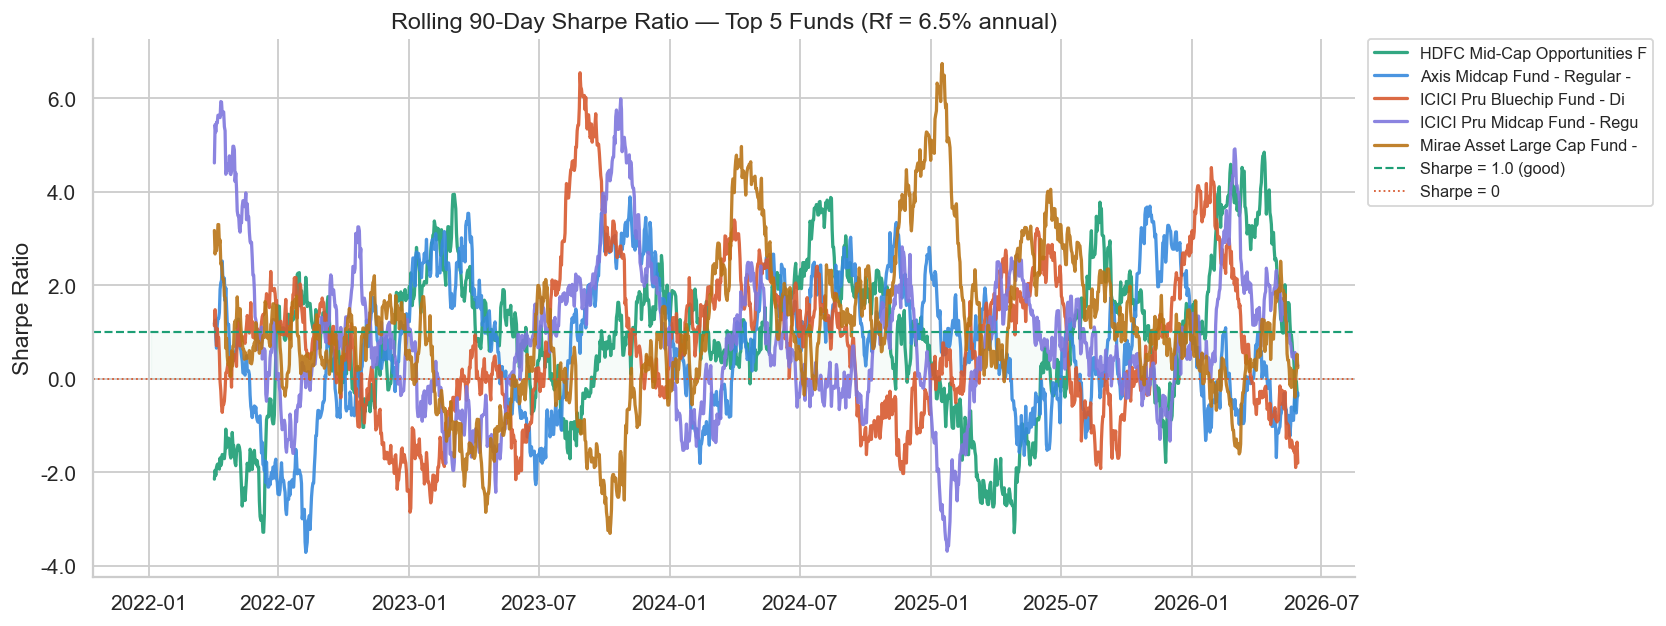

Saved: 22_rolling_sharpe.png


In [5]:
if not scorecard.empty and 'amfi_code' in scorecard.columns:
    scorecard['amfi_code'] = scorecard['amfi_code'].astype(str)
    top5_codes = scorecard.head(5)['amfi_code'].tolist()
else:
    top5_codes = nav_r['amfi_code'].value_counts().head(5).index.tolist()

nav_roll = (nav_r[nav_r['amfi_code'].isin(top5_codes)]
            .pivot_table(index='date', columns='amfi_code',
                         values='daily_return'))

scheme_map = {}
for code in top5_codes:
    match = funds[funds['amfi_code'] == code]['scheme_name']
    scheme_map[code] = match.values[0][:28] if len(match) else code

nav_roll.columns = [scheme_map.get(c, c) for c in nav_roll.columns]

fig, ax = plt.subplots(figsize=(13, 5))
for i, col in enumerate(nav_roll.columns):
    roll_mean = nav_roll[col].rolling(90).mean()
    roll_std  = nav_roll[col].rolling(90).std()
    roll_sh   = (roll_mean - RF_DAILY) / roll_std * np.sqrt(TRADING_DAYS)
    ax.plot(nav_roll.index, roll_sh,
            label=col, color=PALETTE[i], linewidth=1.8, alpha=0.9)

ax.axhline(1.0,  color='#1D9E75', linestyle='--', linewidth=1.2,
           label='Sharpe = 1.0 (good)')
ax.axhline(0.0,  color='#D85A30', linestyle=':', linewidth=1,
           label='Sharpe = 0')
ax.fill_between(nav_roll.index, 0, 1, alpha=0.04, color='#1D9E75')
ax.set_title('Rolling 90-Day Sharpe Ratio — Top 5 Funds (Rf = 6.5% annual)',
             fontsize=13)
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
plt.tight_layout()
plt.savefig(CHARTS_DIR / '22_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 22_rolling_sharpe.png')

In [6]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

txn['amfi_code'] = txn['amfi_code'].astype(str)
funds['amfi_code'] = funds['amfi_code'].astype(str)

txn_sip = txn[txn['transaction_type'] == 'SIP'].copy()

first_tx = (txn.groupby('investor_id')['transaction_date']
            .min()
            .reset_index()
            .rename(columns={'transaction_date': 'first_tx_date'}))

first_tx['cohort_year'] = first_tx['first_tx_date'].dt.year

txn_c = txn_sip.merge(
    first_tx[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

cohort = (txn_c.groupby('cohort_year')
          .agg(
              num_investors   = ('investor_id', 'nunique'),
              total_sip_count = ('amount_inr', 'count'),
              avg_sip_amount  = ('amount_inr', 'mean'),
              total_invested  = ('amount_inr', 'sum'),
              median_sip      = ('amount_inr', 'median'),
          )
          .reset_index())

top_fund_per_cohort = (
    txn_c.groupby(['cohort_year', 'amfi_code'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
         .drop_duplicates('cohort_year')
         .merge(funds[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
         [['cohort_year', 'scheme_name']]
         .rename(columns={'scheme_name': 'top_fund'})
)

cohort = cohort.merge(top_fund_per_cohort, on='cohort_year', how='left')

cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort['total_invested'] = cohort['total_invested'].round(0)

cohort.to_csv(PROCESSED_DIR / 'cohort_analysis.csv', index=False)

display(cohort)
print('Saved: cohort_analysis.csv')

,cohort_year,num_investors,total_sip_count,avg_sip_amount,total_invested,median_sip,top_fund
0,2024,4624,19549,"10,996.890000",214978121,"5,131.000000",ICICI Pru Bluechip Fund - Direct - Growth
1,2025,138,167,"13,505.210000",2255370,"6,240.000000",SBI Small Cap Fund - Direct Plan - Growth


Saved: cohort_analysis.csv


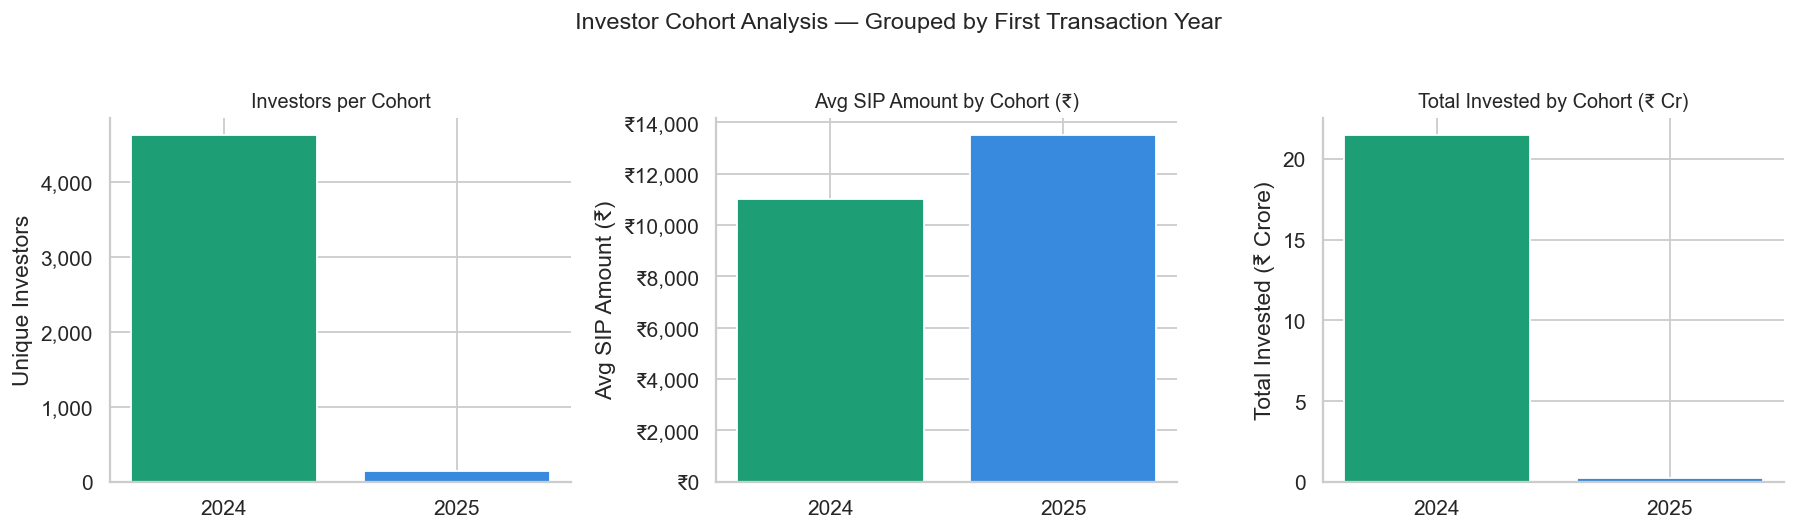

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(cohort['cohort_year'].astype(str), cohort['num_investors'],
            color=PALETTE[:len(cohort)], edgecolor='white')
axes[0].set_title('Investors per Cohort', fontsize=11)
axes[0].set_ylabel('Unique Investors')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[1].bar(cohort['cohort_year'].astype(str), cohort['avg_sip_amount'],
            color=PALETTE[:len(cohort)], edgecolor='white')
axes[1].set_title('Avg SIP Amount by Cohort (₹)', fontsize=11)
axes[1].set_ylabel('Avg SIP Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

axes[2].bar(cohort['cohort_year'].astype(str), cohort['total_invested'] / 1e7,
            color=PALETTE[:len(cohort)], edgecolor='white')
axes[2].set_title('Total Invested by Cohort (₹ Cr)', fontsize=11)
axes[2].set_ylabel('Total Invested (₹ Crore)')

plt.suptitle('Investor Cohort Analysis — Grouped by First Transaction Year',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '24_cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
sip_only = (txn[txn['transaction_type'] == 'SIP']
            .sort_values(['investor_id','transaction_date'])
            .copy())

sip_only['gap_days'] = (sip_only
                        .groupby('investor_id')['transaction_date']
                        .diff()
                        .dt.days)

sip_count = sip_only.groupby('investor_id').size().rename('sip_count')

continuity = (sip_only.dropna(subset=['gap_days'])
              .groupby('investor_id')
              .agg(
                  avg_gap_days  = ('gap_days', 'mean'),
                  max_gap_days  = ('gap_days', 'max'),
                  min_gap_days  = ('gap_days', 'min'),
              ).reset_index()
              .merge(sip_count.reset_index(), on='investor_id'))

continuity = continuity[continuity['sip_count'] >= 6].copy()
continuity['avg_gap_days'] = continuity['avg_gap_days'].round(1)
continuity['at_risk']      = continuity['avg_gap_days'] > 35

at_risk_pct = continuity['at_risk'].mean() * 100
total_inv   = len(continuity)
at_risk_cnt = continuity['at_risk'].sum()

print(f'Investors with 6+ SIP transactions : {total_inv:,}')
print(f'At-risk investors (avg gap > 35d)   : {at_risk_cnt:,} ({at_risk_pct:.1f}%)')
print(f'Median avg gap (days)               : {continuity["avg_gap_days"].median():.1f}')

continuity.to_csv(PROCESSED_DIR / 'sip_continuity.csv', index=False)
display(continuity.sort_values('avg_gap_days', ascending=False).head(10)
        [['investor_id','sip_count','avg_gap_days','max_gap_days','at_risk']])
print('Saved: sip_continuity.csv')

Investors with 6+ SIP transactions : 1,362
At-risk investors (avg gap > 35d)   : 1,332 (97.8%)
Median avg gap (days)               : 64.7


,investor_id,sip_count,avg_gap_days,max_gap_days,at_risk
1529,INV001890,6,102.600000,207.000000,True
947,INV001156,6,102.400000,175.000000,True
3476,INV004296,6,102.200000,304.000000,True
2681,INV003325,6,101.000000,155.000000,True
424,INV000522,6,100.800000,309.000000,True
501,INV000608,6,100.200000,324.000000,True
1746,INV002166,6,99.200000,248.000000,True
1524,INV001883,6,99.200000,203.000000,True
1111,INV001367,6,99.000000,222.000000,True
1211,INV001491,6,98.800000,260.000000,True


Saved: sip_continuity.csv


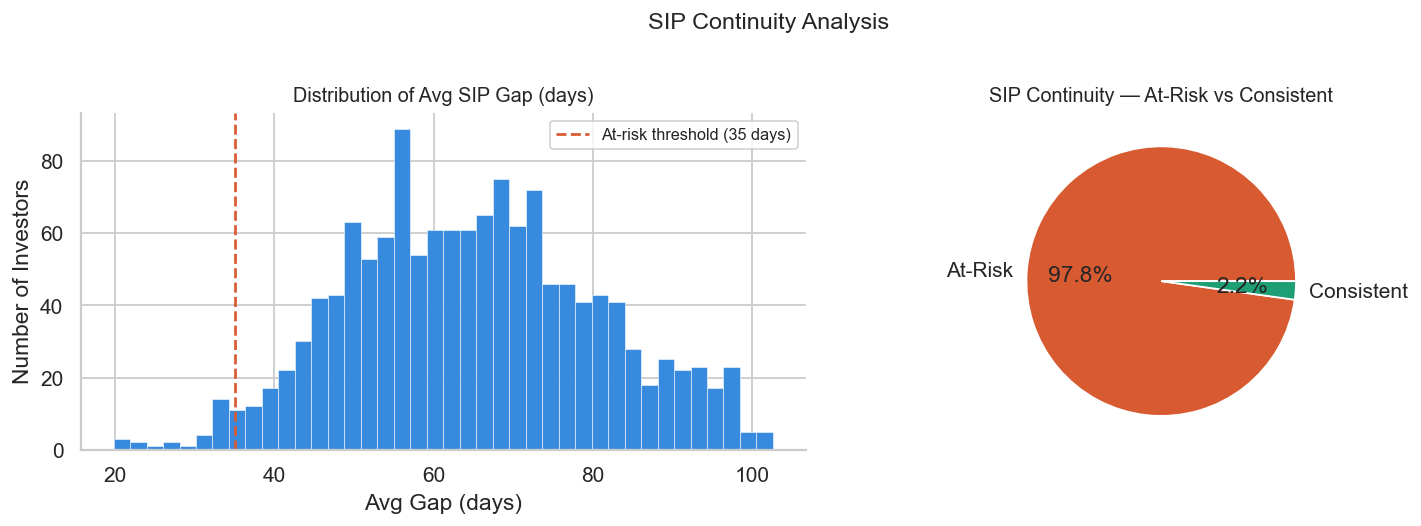

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

continuity['avg_gap_days'].hist(bins=40, ax=axes[0],
                                 color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].axvline(35, color='#D85A30', linewidth=1.5, linestyle='--',
                label='At-risk threshold (35 days)')
axes[0].set_title('Distribution of Avg SIP Gap (days)', fontsize=11)
axes[0].set_xlabel('Avg Gap (days)')
axes[0].set_ylabel('Number of Investors')
axes[0].legend(fontsize=9)

risk_cnt = continuity['at_risk'].value_counts().rename({True:'At-Risk',False:'Consistent'})
axes[1].pie(risk_cnt, labels=risk_cnt.index, autopct='%1.1f%%',
            colors=['#D85A30','#1D9E75'],
            wedgeprops={'linewidth':1,'edgecolor':'white'})
axes[1].set_title('SIP Continuity — At-Risk vs Consistent', fontsize=11)

plt.suptitle('SIP Continuity Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '25_sip_continuity.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import sys
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
from recommender import recommend, full_recommendation_report

for appetite in ['Low', 'Moderate', 'High']:
    print(f'\n{"-"*55}')
    print(f'  Risk Appetite: {appetite}')
    print(f'{"-"*55}')
    result = recommend(appetite)
    display(result)


-------------------------------------------------------
  Risk Appetite: Low
-------------------------------------------------------


,scheme_name,fund_house,category,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct,max_drawdown_pct,aum_crore
1,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Low,7.680000,7.680000,0.740000,-2.620000,39116
2,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Low,6.180000,6.180000,0.600000,-3.810000,27623
3,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Low,5.140000,5.140000,0.790000,-3.660000,38995



-------------------------------------------------------
  Risk Appetite: Moderate
-------------------------------------------------------


,scheme_name,fund_house,category,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct,max_drawdown_pct,aum_crore
1,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.060000,14.840000,1.550000,-17.410000,6434
2,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.060000,14.810000,1.460000,-17.070000,11361
3,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.030000,14.410000,0.800000,-26.590000,41553



-------------------------------------------------------
  Risk Appetite: High
-------------------------------------------------------


,scheme_name,fund_house,category,risk_category,sharpe_ratio,return_3yr_pct,expense_ratio_pct,max_drawdown_pct,aum_crore
1,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,High,0.960000,18.230000,1.560000,-21.920000,47469
2,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High,0.950000,18.080000,1.360000,-21.840000,979
3,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Very High,0.940000,23.390000,1.430000,-13.350000,19259


In [11]:
import plotly.express as px

print("STEP 1")

report = full_recommendation_report()

print("STEP 2")

if report is None or len(report) == 0:
    raise ValueError("full_recommendation_report() returned empty or None")

report.to_csv(PROCESSED_DIR / 'recommendation_report.csv', index=False)

print("STEP 3")
print("Report shape:", report.shape)

required_cols = {'sharpe_ratio', 'risk_appetite_input', 'scheme_name'}

if required_cols.issubset(report.columns):

    print("STEP 4")

    chart_data = report.dropna(subset=['sharpe_ratio'])

    fig = px.bar(
        chart_data,
        x='scheme_name',
        y='sharpe_ratio',
        color='risk_appetite_input',
        barmode='group',
        color_discrete_map={
            'Low': '#1D9E75',
            'Moderate': '#378ADD',
            'High': '#D85A30'
        },
        title='Recommended Funds by Risk Appetite — Sharpe Ratio Comparison',
        labels={
            'scheme_name': 'Fund',
            'sharpe_ratio': 'Sharpe Ratio',
            'risk_appetite_input': 'Risk Appetite'
        }
    )

    print("STEP 5")

    fig.update_layout(
        height=380,
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis_tickangle=-30
    )

    fig.update_xaxes(showgrid=False)
    fig.update_yaxes(gridcolor='#f0f0f0')

    print("STEP 6")

else:
    print("Missing required columns")
    print(report.columns)

print("STEP 7")
print("RECOMMENDER CELL FINISHED")

STEP 1
STEP 2
STEP 3
Report shape: (9, 11)
STEP 4
STEP 5
STEP 6
STEP 7
RECOMMENDER CELL FINISHED


In [13]:
import pandas as pd

print("START")

hold = holdings.copy()

hold['weight_pct'] = pd.to_numeric(hold['weight_pct'], errors='coerce')
hold['amfi_code'] = hold['amfi_code'].astype(str)

hold = hold.dropna(subset=['amfi_code', 'sector', 'weight_pct'])

print("Building sector weights")

sector_wts = (
    hold.groupby(['amfi_code', 'sector'], as_index=False)['weight_pct']
    .sum()
)

print("Building total weights")

total_wts = (
    sector_wts.groupby('amfi_code', as_index=False)['weight_pct']
    .sum()
    .rename(columns={'weight_pct': 'total_weight'})
)

print("Merging totals")

sector_wts = sector_wts.merge(
    total_wts,
    on='amfi_code',
    how='left'
)

sector_wts['weight_norm'] = (
    sector_wts['weight_pct'] /
    sector_wts['total_weight']
)

sector_wts['hhi_contrib'] = (
    sector_wts['weight_norm'] ** 2
)

print("Calculating HHI")

hhi = (
    sector_wts.groupby('amfi_code', as_index=False)['hhi_contrib']
    .sum()
    .rename(columns={'hhi_contrib': 'hhi'})
)

funds['amfi_code'] = funds['amfi_code'].astype(str)

funds_clean = (
    funds[
        ['amfi_code', 'scheme_name', 'category', 'fund_house']
    ]
    .drop_duplicates(subset=['amfi_code'])
)

print("Merging fund metadata")

hhi = hhi.merge(
    funds_clean,
    on='amfi_code',
    how='left'
)

hhi['hhi'] = hhi['hhi'].round(4)

hhi['concentration'] = pd.cut(
    hhi['hhi'],
    bins=[0, 0.15, 0.25, 1.0],
    labels=['Diversified', 'Moderate', 'Concentrated'],
    include_lowest=True
)

print("Saving CSV")

output_file = PROCESSED_DIR / 'sector_hhi.csv'
hhi.to_csv(output_file, index=False)

print("HHI distribution:")
print(hhi['concentration'].value_counts(dropna=False).to_string())
print()

top15 = hhi.sort_values('hhi', ascending=False)[
    ['scheme_name', 'category', 'hhi', 'concentration']
].head(15)

print(top15.to_string(index=False))

print()
print(f"Saved: {output_file}")
print("DONE")

START
Building sector weights
Building total weights
Merging totals
Calculating HHI
Merging fund metadata
Saving CSV
HHI distribution:
concentration
Moderate        27
Concentrated     4
Diversified      3

                                          scheme_name category      hhi concentration
                Axis Bluechip Fund - Regular - Growth   Equity 0.296800  Concentrated
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity 0.255100  Concentrated
    HDFC Mid-Cap Opportunities Fund - Direct - Growth   Equity 0.253200  Concentrated
                UTI Flexi Cap Fund - Regular - Growth   Equity 0.251300  Concentrated
                   DSP Midcap Fund - Regular - Growth   Equity 0.241100      Moderate
             ICICI Pru Midcap Fund - Regular - Growth   Equity 0.238600      Moderate
                       Nippon India ETF Nifty 50 BeES   Equity 0.237500      Moderate
            SBI Small Cap Fund - Direct Plan - Growth   Equity 0.232400      Moderate
    ICICI Pru Value

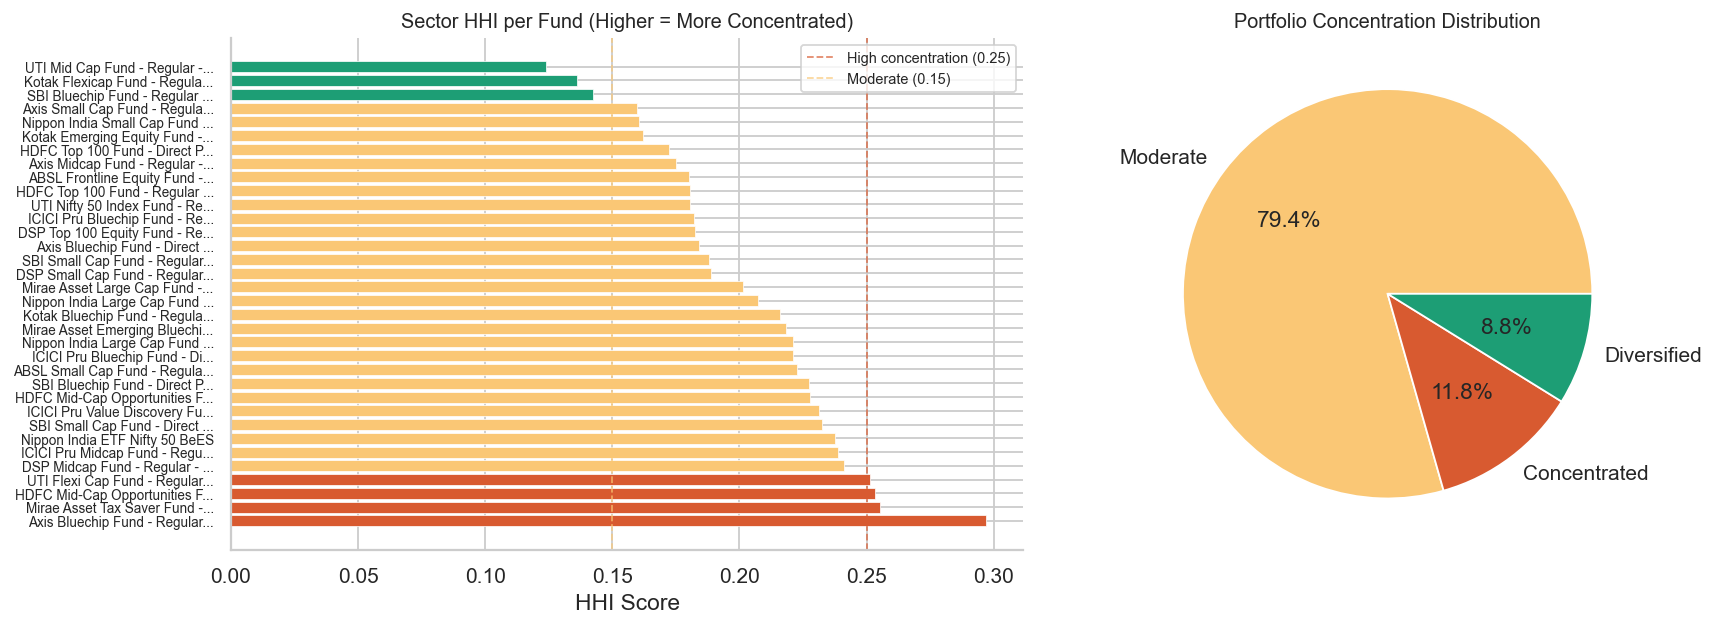

In [14]:
hhi_plot = hhi.dropna(subset=['hhi','scheme_name']).sort_values('hhi', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {'Concentrated':'#D85A30','Moderate':'#FAC775','Diversified':'#1D9E75'}
colors = [color_map.get(str(c), '#888780') for c in hhi_plot['concentration']]
axes[0].barh(range(len(hhi_plot)), hhi_plot['hhi'],
             color=colors, edgecolor='white', linewidth=0.4)
axes[0].set_yticks(range(len(hhi_plot)))
axes[0].set_yticklabels(
    [s[:28]+'...' if len(str(s))>30 else str(s) for s in hhi_plot['scheme_name']],
    fontsize=7.5)
axes[0].axvline(0.25, color='#D85A30', linewidth=1, linestyle='--', alpha=0.7,
                label='High concentration (0.25)')
axes[0].axvline(0.15, color='#FAC775', linewidth=1, linestyle='--', alpha=0.7,
                label='Moderate (0.15)')
axes[0].set_title('Sector HHI per Fund (Higher = More Concentrated)', fontsize=11)
axes[0].set_xlabel('HHI Score')
axes[0].legend(fontsize=8)

conc_cnt = hhi['concentration'].value_counts()
axes[1].pie(conc_cnt, labels=conc_cnt.index, autopct='%1.1f%%',
            colors=[color_map.get(str(k),'#888780') for k in conc_cnt.index],
            wedgeprops={'linewidth':1,'edgecolor':'white'})
axes[1].set_title('Portfolio Concentration Distribution', fontsize=11)

plt.tight_layout()
plt.savefig(CHARTS_DIR / '27_sector_hhi.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
files = ['var_cvar_report.csv','cohort_analysis.csv','sip_continuity.csv',
         'recommendation_report.csv','sector_hhi.csv']
print('Day 6 deliverables saved to data/processed/:')
for f in files:
    p = PROCESSED_DIR / f
    rows = len(pd.read_csv(p)) if p.exists() else 'NOT FOUND'
    print(f'  {f:<35} {rows}')

print(f'\nChart PNGs (Day 6):')
for f in sorted(CHARTS_DIR.glob('2[2-9]_*.png')):
    print(f'  {f.name}')

Day 6 deliverables saved to data/processed/:
  var_cvar_report.csv                 40
  cohort_analysis.csv                 2
  sip_continuity.csv                  1362
  recommendation_report.csv           9
  sector_hhi.csv                      34

Chart PNGs (Day 6):
  22_rolling_sharpe.png
  23_var_cvar.png
  24_cohort_analysis.png
  25_sip_continuity.png
  27_sector_hhi.png
